# LDV Cable Coupling — Per-Frequency Analysis

Slim driver: all reusable logic lives in the [`ldv_analysis/`](ldv_analysis) package.
Edit the package, then re-run the relevant cells here.

| § | Content |
|---|---|
| 0 | Imports & plot style |
| 1 | Dataset selection |
| 2 | Data loading (cached after first call) |
| 3 | Initial geometry & static sag |
| 4 | Reference δL(t) from shaker |
| 5 | **Per-frequency analysis** (main) |
| 6 | Coupling efficiency summary η(f) |
| 7 | Interactive QC dashboard |


---
## § 0  Imports & Plot Style


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Editable reload while iterating on the package
%load_ext autoreload
%autoreload 2

import ldv_analysis as la
from ldv_analysis import config, io, signal, geometry, strain, analysis, plotting, widgets
from ldv_analysis.config import TARGET_FREQS

plt.rcParams.update({
    "font.size": 12, "font.family": "serif", "font.serif": ["DejaVu Serif"], 
    "mathtext.fontset": "dejavuserif",
    "figure.dpi": 130, "savefig.dpi": 300, "figure.autolayout": True,
    "axes.titlesize": 11, "axes.labelsize": 10, "axes.linewidth": 0.8,       # 13, 12
    "xtick.direction": "in", "ytick.direction": "in",
    "xtick.labelsize": 10, "ytick.labelsize": 10,
    "axes.grid": True, "grid.alpha": 0.3, "grid.linestyle": "--",
    "lines.linewidth": 1.4, "image.cmap": "RdBu_r",
})

print(f"{len(la.ALL_DATASETS)} datasets in catalogue.")


46 datasets in catalogue.


---
## § 1  Dataset Selection

Edit `ACTIVE_LABELS` to pick which datasets get loaded.
The catalogue (`ldv_analysis/config.py::ALL_DATASETS`) holds 49 entries
across 7 cables × 3 gap sizes × Sag/IS/TAPE variants + linearity tests.


In [2]:
# Examples — uncomment the set you want.

## 5 cm
# ACTIVE_LABELS = [f"Cable{i}_5cm" for i in range(1, 8)]
# ACTIVE_LABELS = [f"Cable{i}_5cm_Sag" for i in range(1, 8)]

## 10 cm
#ACTIVE_LABELS = [f"Cable{i}_10cm" for i in range(1, 8)]
ACTIVE_LABELS = [f"Cable{i}_10cm" for i in range(6, 7)]

# ACTIVE_LABELS = [f"Cable{i}_10cm_Sag" for i in range(1, 8)]

## 15 cm
# ACTIVE_LABELS = [f"Cable{i}_15cm" for i in range(1, 8)]
#ACTIVE_LABELS = [f"Cable{i}_15cm_Sag" for i in range(1, 8)]


## 15 cm Sag (default)
#ACTIVE_LABELS = [f"Cable{i}_15cm_Sag" for i in range(1, 8)]
# Also include the non sag variants for comparison:
# ACTIVE_LABELS = [f"Cable{i}_15cm" for i in range(1, 8)] + [f"Cable{i}_15cm_Sag" for i in range(1, 8)]

# only cable 4, 6 and 7
# ACTIVE_LABELS = [
#     "Cable5_5cm", #"Cable6_5cm", "Cable7_5cm",
#     "Cable5_5cm_Sag", #"Cable6_5cm_Sag", "Cable7_5cm_Sag",

#     "Cable6_10cm", #"Cable6_10cm", "Cable7_10cm",
#     "Cable6_10cm_Sag", #"Cable6_10cm_Sag", "Cable7_10cm_Sag",

#     "Cable5_15cm", #"Cable6_15cm", "Cable7_15cm",
#     "Cable5_15cm_Sag", #"Cable6_15cm_Sag", "Cable7_15cm_Sag",
#     #"Cable7_15cm_NO_Tape",
# ]

# ACTIVE_LABELS = [
#     "Cable7_5cm", #"Cable6_5cm", "Cable7_5cm",
#     "Cable7_10cm", #"Cable6_5cm", "Cable7_5cm",
#     "Cable7_5cm_Sag", #"Cable6_5cm_Sag", "Cable7_5cm_Sag",
#     "Cable7_10cm_Sag", #"Cable6_5cm", "Cable7_5cm",
#     "Cable7_15cm", #"Cable6_5cm", "Cable7_5cm",
#     "Cable7_15cm_Sag", #"Cable6_5cm_Sag", "Cable7_5cm_Sag",
# ]

## Linearity tests (different sweep timing)
# ACTIVE_LABELS = [
#     "LinTest_Cable5_5cm",
#     "LinTest_Cable6_5cm",
#     "LinTest_Cable7_5cm",
#     "LinTest_Cable7_10cm_Sag",
# ]

ACTIVE_LABELS = ["Cable7_5cm", "Cable7_10cm", "Cable7_15cm"]  # taut

DATASETS = config.select_datasets(ACTIVE_LABELS)
print(f"Active: {[ds['label'] for ds in DATASETS]}")
print(f"Target frequencies: {TARGET_FREQS} Hz")


Active: ['Cable7_5cm', 'Cable7_10cm', 'Cable7_15cm']
Target frequencies: [2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30, 32, 34, 36, 38, 40, 42, 44, 46, 48, 50, 52, 54, 56, 58, 60, 62, 64, 66, 68, 70, 72, 74, 76, 78, 80, 82, 84, 86, 88, 90, 92, 94, 96, 98, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 210, 220, 230, 240, 250, 275, 300, 325, 350, 375, 400, 425, 450, 475] Hz


---
## § 2  Data Loading

`io.load_cable_dataset(cfg)` reads cable + shaker .mat files, sorts sensors by x,
removes dead channels, and selects the active shaker channel. Results are cached
in-memory keyed by `cfg['label']`, so re-running this cell is free after the
first call (use `io.clear_cache()` to force reload).


In [3]:
for cfg in DATASETS:
    print(f"Loading: {cfg['label']}")
    io.load_cable_dataset(cfg)
    print(f"  {cfg['n_sensors']} sensors  |  {cfg['n_samples']} samples  |  "
          f"fs = {cfg['fs']:.0f} Hz  |  gap = {cfg['gap_m']*100:.0f} cm")
    print(f"  x-range: {cfg['x'].min()*1e3:.1f} - {cfg['x'].max()*1e3:.1f} mm")
    print(f"  shaker peak |v|:  x={np.abs(cfg['sh_vx']).max()*1e3:.2f}  "
          f"y={np.abs(cfg['sh_vy']).max()*1e3:.2f}  "
          f"z={np.abs(cfg['sh_vz']).max()*1e3:.2f}  [mm/s]")
print("\nAll datasets loaded.")


Loading: Cable7_5cm
  [Cable7_5cm] shaker active channel: idx=9 (of 10 channels; 1 non-zero)
  9 sensors  |  60000 samples  |  fs = 5000 Hz  |  gap = 5 cm
  x-range: 6.0 - 48.5 mm
  shaker peak |v|:  x=52.15  y=68.11  z=51.64  [mm/s]
Loading: Cable7_10cm
  [Cable7_10cm] shaker active channel: idx=17 (of 18 channels; 1 non-zero)
  17 sensors  |  60000 samples  |  fs = 5000 Hz  |  gap = 10 cm
  x-range: 8.3 - 100.0 mm
  shaker peak |v|:  x=58.85  y=75.18  z=70.99  [mm/s]
Loading: Cable7_15cm
  [Cable7_15cm] shaker active channel: idx=17 (of 18 channels; 1 non-zero)
  17 sensors  |  60000 samples  |  fs = 5000 Hz  |  gap = 15 cm
  x-range: 8.6 - 150.5 mm
  shaker peak |v|:  x=58.59  y=37.37  z=57.26  [mm/s]

All datasets loaded.


---
## § 3  Initial Geometry & Static Sag

`plotting.plot_initial_geometry` plots side+top views and prints the chord
direction, sag, and quasi-static η_pred = 1/(1+½(w₀/r)²). It also writes
`chord_unit`, `chord_len`, `static_sag`, `eta_pred`, etc. into each cfg.

**Sag method options** (edit the two flags in the cell below):

| `SAG_USE_3D` | `SAG_USE_PARABOLA` | Description |
|---|---|---|
| `False` | `False` | x-z plane projection only (2-D) |
| `True`  | `False` | Full 3-D perpendicular distance from chord |
| `False` | `True`  | x-z plane + parabola fit (outlier-robust) |
| `True`  | `True`  | 3-D perpendicular + parabola fit |

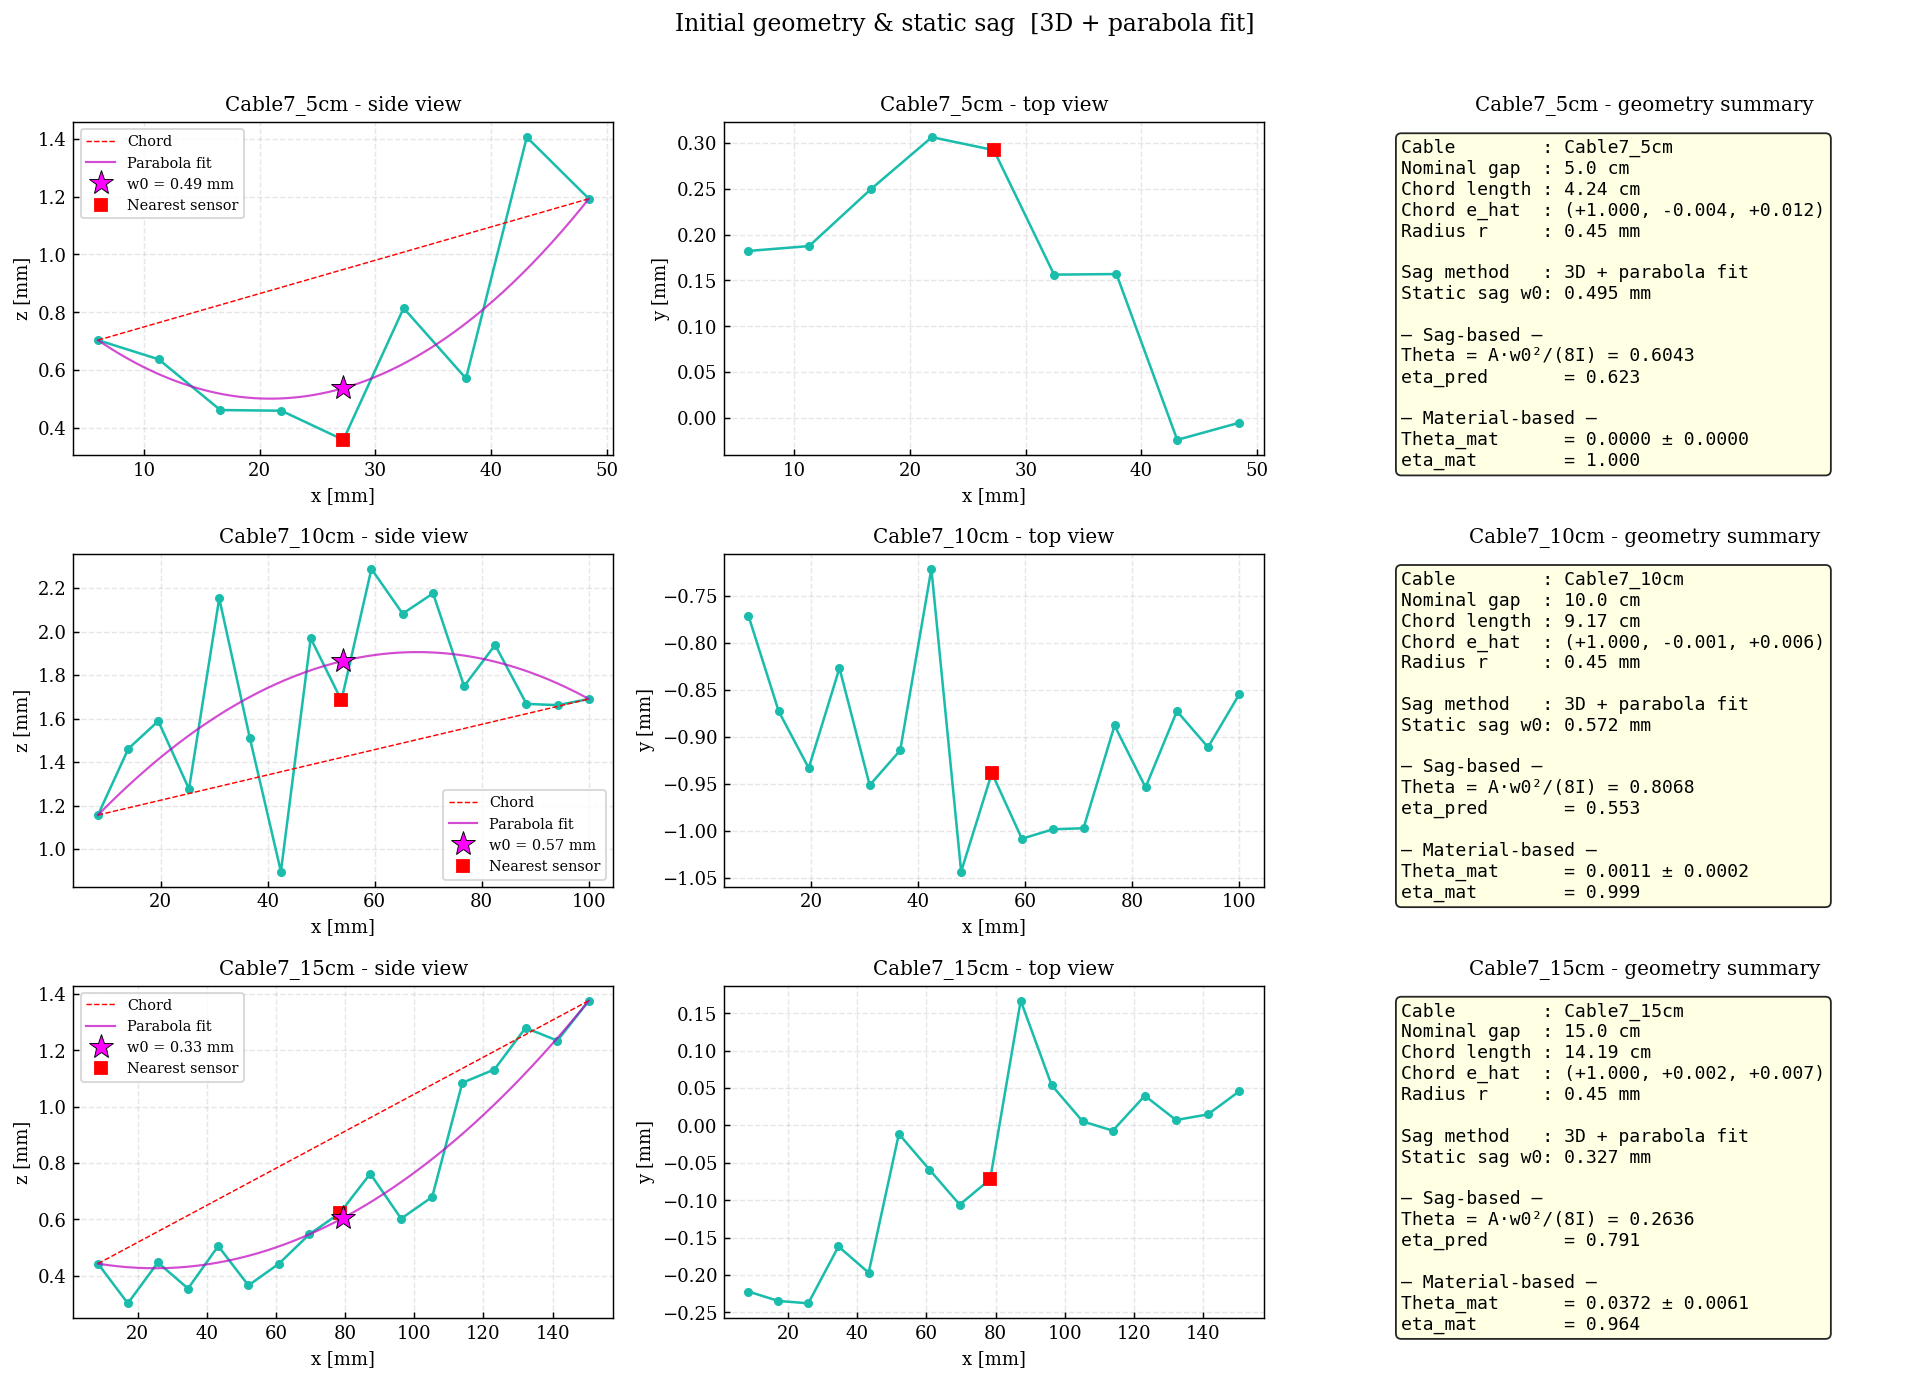

In [4]:
# ─── Sag method ─────────────────────────────────────────────────────────────
SAG_USE_3D       = True   # Option 1 — True: full 3-D perpendicular from chord
                           #            False: x-z plane projection only
SAG_USE_PARABOLA = True  # Option 2 — True: fit parabola before measuring sag
                           #            False: use raw sensor positions

plotting.plot_initial_geometry(DATASETS,
                                sag_use_3d=SAG_USE_3D,
                                sag_use_parabola=SAG_USE_PARABOLA)


---
## § 4  Reference δL(t) from Shaker

1. Integrate the 3-component shaker velocity → 3-D displacement.
2. Project onto the cable chord → δL(t), the axial input.
3. Reference strain ε_ref(t) = δL / L_chord (uniform across the gap).
4. End-sensor cross-check: ε_ref_end from the first/last LDV points only.


Cable7_5cm            peak δL = 189.93 μm   peak ε_ref = 4476.24 μm/m   peak ε_ref_end = 4201.71 μm/m
Cable7_10cm           peak δL = 134.51 μm   peak ε_ref = 1466.15 μm/m   peak ε_ref_end = 2567.77 μm/m
Cable7_15cm           peak δL = 102.28 μm   peak ε_ref = 720.59 μm/m   peak ε_ref_end = 734.16 μm/m


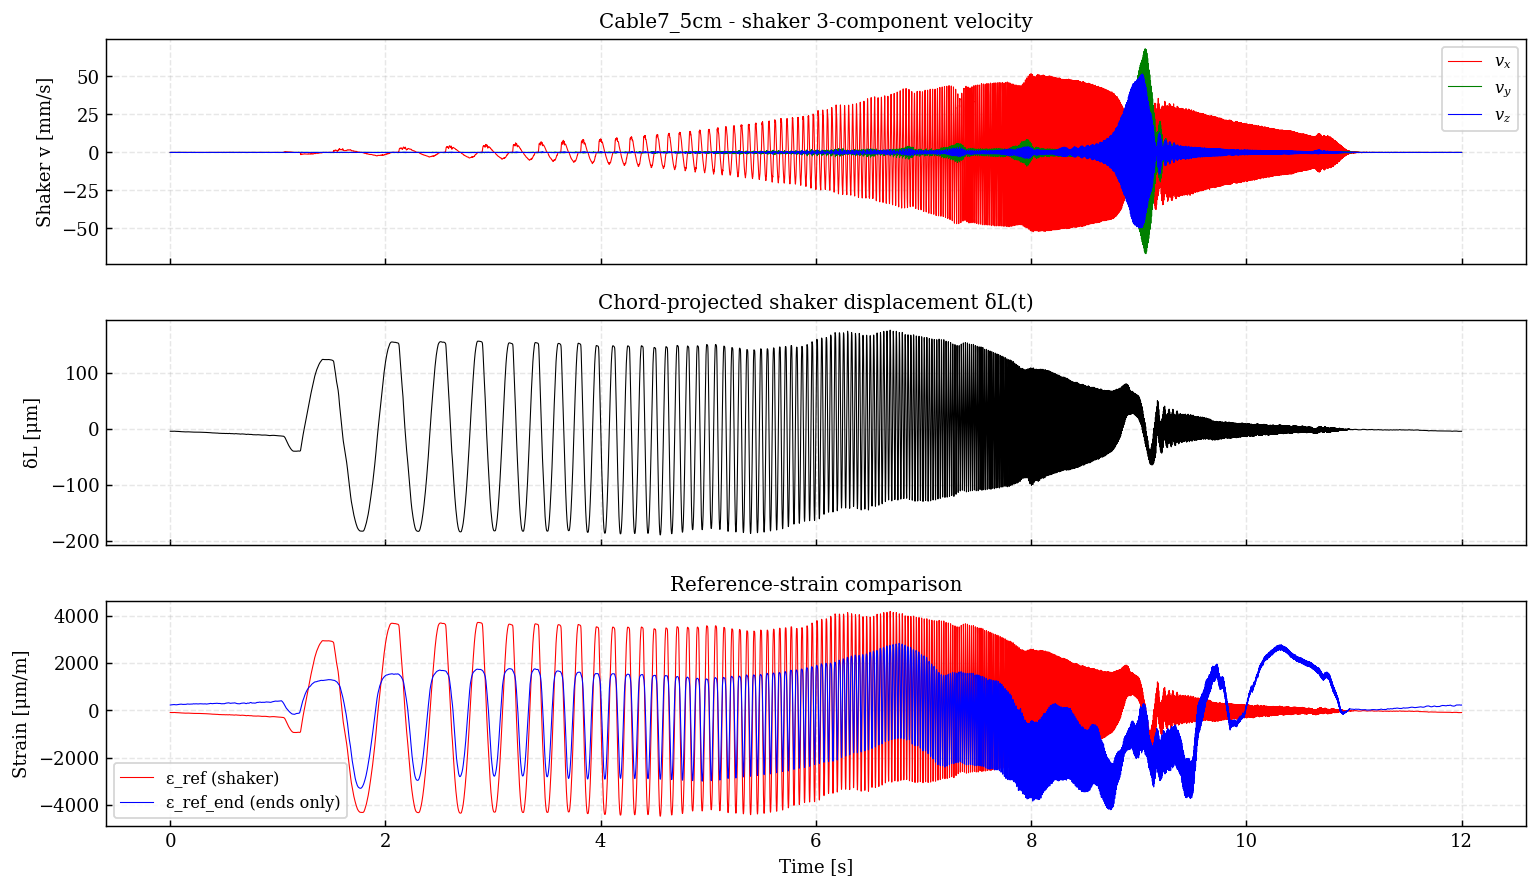

In [5]:
for cfg in DATASETS:
    u_sh_x = signal.integrate_fft(cfg['sh_vx'], cfg['dt'])
    u_sh_y = signal.integrate_fft(cfg['sh_vy'], cfg['dt'])
    u_sh_z = signal.integrate_fft(cfg['sh_vz'], cfg['dt'])

    delta_L = geometry.project_onto_chord(u_sh_x, u_sh_y, u_sh_z, cfg['chord_unit'])
    if cfg['shaker_end'] == 'right':   # Theoretically should be left but then for some reason the sign is flipped in the data, so we correct it here. SHOULD BE CHECKED
        delta_L = -delta_L
    eps_ref = delta_L / cfg['chord_len']

    # End-sensor reference
    vx_ends = cfg['vx'][:, [cfg['idx_left'], cfg['idx_right']]]
    vy_ends = cfg['vy'][:, [cfg['idx_left'], cfg['idx_right']]]
    vz_ends = cfg['vz'][:, [cfg['idx_left'], cfg['idx_right']]]
    ux_ends = signal.integrate_fft(vx_ends, cfg['dt'])
    uy_ends = signal.integrate_fft(vy_ends, cfg['dt'])
    uz_ends = signal.integrate_fft(vz_ends, cfg['dt'])
    L_ends = np.linalg.norm(cfg['XYZ'][cfg['idx_right']] - cfg['XYZ'][cfg['idx_left']])
    u_axial_ends = geometry.project_onto_chord(ux_ends, uy_ends, uz_ends, cfg['chord_unit'])
    eps_ref_end = (u_axial_ends[:, 1] - u_axial_ends[:, 0]) / L_ends

    cfg.update(dict(
        u_sh_x=u_sh_x, u_sh_y=u_sh_y, u_sh_z=u_sh_z,
        delta_L=delta_L, eps_ref=eps_ref,
        u_axial_ends=u_axial_ends, eps_ref_end=eps_ref_end,
    ))
    print(f"{cfg['label']:20s}  peak δL = {np.abs(delta_L).max()*1e6:.2f} μm   "
          f"peak ε_ref = {np.abs(eps_ref).max()*1e6:.2f} μm/m   "
          f"peak ε_ref_end = {np.abs(eps_ref_end).max()*1e6:.2f} μm/m")

# Quick visual: shaker components + δL + reference-strain comparison for one cfg
cfg = DATASETS[min(0, len(DATASETS)-1)]
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
axes[0].plot(cfg['t'], cfg['sh_vx']*1e3, lw=0.6, color='r', label='$v_x$')
axes[0].plot(cfg['t'], cfg['sh_vy']*1e3, lw=0.6, color='g', label='$v_y$')
axes[0].plot(cfg['t'], cfg['sh_vz']*1e3, lw=0.6, color='b', label='$v_z$')
axes[0].set_ylabel('Shaker v [mm/s]'); axes[0].legend(fontsize=9, loc='upper right')
axes[0].set_title(f"{cfg['label']} - shaker 3-component velocity")

axes[1].plot(cfg['t'], cfg['delta_L']*1e6, color='k', lw=0.6)
axes[1].set_ylabel('δL [μm]'); axes[1].set_title('Chord-projected shaker displacement δL(t)')

axes[2].plot(cfg['t'], cfg['eps_ref']*1e6, color='red', lw=0.6, label='ε_ref (shaker)')
axes[2].plot(cfg['t'], cfg['eps_ref_end']*1e6, color='blue', lw=0.6, label='ε_ref_end (ends only)')
axes[2].set_ylabel('Strain [μm/m]'); axes[2].set_xlabel('Time [s]')
axes[2].set_title('Reference-strain comparison')
axes[2].legend(fontsize=9)
plt.tight_layout(); plt.show()


---
## § 5  Per-Frequency Analysis

For each (cfg, f_target) we window, bandpass, integrate, compute strain by two
methods, and compare cable elongation δxₗ vs reference δL → η(t).
`per_frequency_qc` returns a dict; we stash it in `cfg['per_freq'][f]`.


In [6]:
for cfg in DATASETS:
    cfg['per_freq'] = {}
    for f in TARGET_FREQS:
        res = analysis.per_frequency_qc(cfg, f)
        if res is None:
            continue
        cfg['per_freq'][f] = res

# Show one QC dashboard as a sanity check (comment out for batch runs):
cfg0 = DATASETS[0]
f0 = next(iter(cfg0['per_freq']))
# plotting.plot_per_frequency_qc(cfg0, cfg0['per_freq'][f0], ref='ends')


---
## § 6  Coupling Efficiency Summary η(f)

Aggregate the per-frequency results into one η-vs-f curve per dataset.
Dotted horizontal line = quasi-static prediction η = 1/(1+Θ).


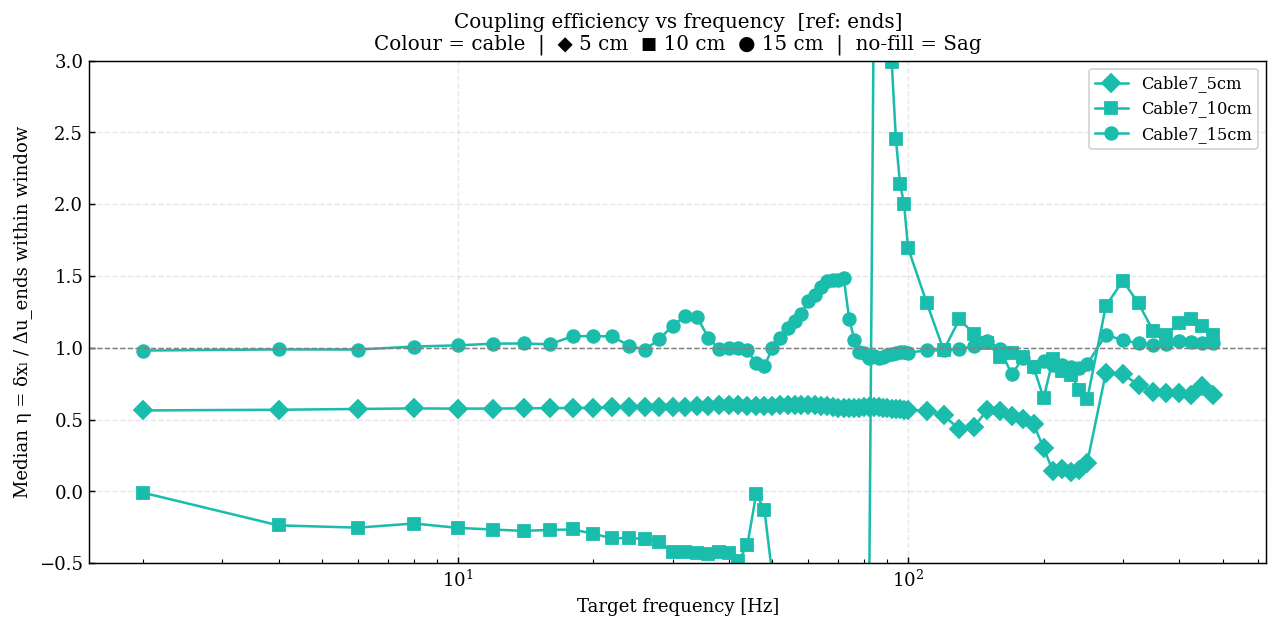


Cable7_5cm   (Theta=0.604, eta_pred=0.623)
------------------------------------------------------------
Cable7_10cm   (Theta=0.807, eta_pred=0.553)
------------------------------------------------------------
Cable7_15cm   (Theta=0.264, eta_pred=0.791)
------------------------------------------------------------


In [7]:
plotting.plot_coupling_summary(DATASETS, ref='ends', logx=True, ylim=(-0.5, 3)) #,estimator='envelope')
#plotting.plot_coupling_summary(DATASETS, ref='shaker', logx=True, ylim=(-0.5, 2.0))
#plotting.plot_coupling_summary(DATASETS, ref='shaker_end)', logx=True, ylim=(-0.5, 2.0))


#plotting.plot_coupling_summary(DATASETS, ref='ends', logx=False, ylim=(-0.5, 2.0))
#plotting.plot_coupling_summary(DATASETS, ref='shaker', logx=False, ylim=(-0.5, 2.0))


---
## § 7  Interactive QC Dashboard

Pick cable / frequency / bandwidth / window and re-run the analysis on demand.


In [ ]:
widgets.qc_dashboard(DATASETS)

In [ ]:
widgets.strain_comparison_dashboard(DATASETS)